In [2]:
from dotenv import load_dotenv
load_dotenv()

True

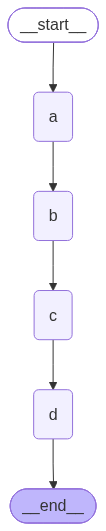

In [3]:
from IPython.display import Image, display

from typing import Any
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    state: list


def create_node_fn(node_secret: str):
    """Create a node function that adds its secret to the state."""
    def node_function(state):
        print(f"Adding {node_secret} to {state['state']}")
        return {"state": [node_secret]}
    return node_function


# Add nodes
builder = StateGraph(State)

builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow - linear sequence
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
result = graph.invoke({"state": []})

print(f"Final state: {result['state']}")

result

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm B"]
Adding I'm D to ["I'm C"]
Final state: ["I'm D"]


{'state': ["I'm D"]}

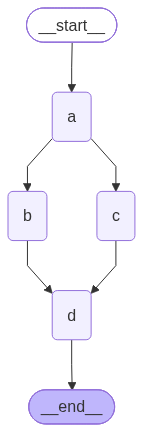

In [5]:
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow - fan-out from a to b and c, then fan-in to d
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
An error occurred: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


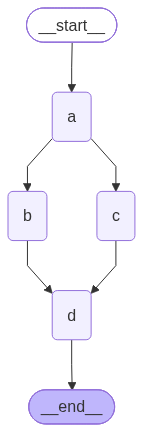

In [7]:
import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    state: Annotated[list, operator.add]

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm D"]}

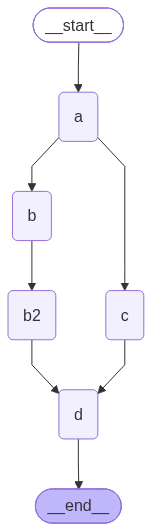

In [9]:
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("b2", create_node_fn("I'm B2"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")  # Both b2 and c must complete before d
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

In [11]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI()

In [12]:
class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

In [13]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults

def search_web(state):
    """Retrieve docs from web search"""
    # Search
    tavily_search = TavilySearchResults(max_results=3)
    search_docs = tavily_search.invoke(state['question'])

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'\n{doc["content"]}\n'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def search_wikipedia(state):
    """Retrieve docs from wikipedia"""
    # Search
    search_docs = WikipediaLoader(query=state['question'],
                                  load_max_docs=2).load()

    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'\n{doc.page_content}\n'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

def generate_answer(state):
    """Node to answer a question"""
    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question,
                                                  context=context)

    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])

    # Append it to state
    return {"answer": answer}

C:\Users\localadmin\AppData\Local\Temp\ipykernel_3048\131027982.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


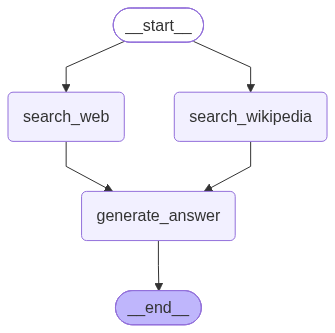

In [14]:
# Add nodes
builder = StateGraph(State)

# Initialize each node
builder.add_node("search_web", search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow - parallel search, then generate answer
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
result = graph.invoke({"question": "How were Nvidia's Q2 2024 earnings"})
result["answer"].content

"Nvidia's Q2 2024 earnings were impressive, with the company reporting revenue of $30.0 billion, representing a 122% increase from the previous year. Their net income also saw a significant increase to $16.952 billion. The earnings per diluted share for the quarter were $0.68, which was up 152% from the previous year. These strong financial results were primarily driven by the exceptional performance of Nvidia's data center business, which saw record revenue of $26.3 billion, a 154% increase year over year. The gaming division also showed growth, with revenue increasing by 22% from the previous year. Overall, Nvidia's Q2 2024 earnings outperformed market expectations and demonstrated the company's position as a key player in the technology industry, particularly in areas like GPUs, deep learning, and AI."